In [1]:
import os
os.chdir('../../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import kmedoids 
import chemiscope

from src.datasets import QM9Dataset
from src.features import get_features_xyz, get_raw_xyz_features
from src.helper_functions import get_structures
from config.configs import get_rattle

In [3]:
mol_ids = ["qm9_1237", "qm9_1244", "qm9_1246", "qm9_1248", "qm9_1474", "qm9_1476", "qm9_1478", "qm9_1486", "qm9_1447", "qm9_1449"]
qm9_loader = QM9Dataset(required_mol_ids=mol_ids)

qm9_loader.load()
#rattle = get_rattle()
frames = qm9_loader.run_stress_test(mol_ids=mol_ids)
frames_rotated = qm9_loader.run_stress_test(mol_ids=mol_ids, rotated=True)

2026-03-10 13:42:19.726 | INFO     | src.datasets:load:109 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-03-10 13:42:19.742 | INFO     | src.geometry:generate_stress_test:79 - Generating Stress Test (Seed=40, Max Bond Rattle=0.05Å, Max Angle Rattle=5.0°)...
2026-03-10 13:42:20.228 | INFO     | src.geometry:generate_stress_test:208 - Generated 210 frames. Failed molecules: 0
2026-03-10 13:42:20.247 | SUCCESS  | src.geometry:generate_stress_test:212 - Saved stress test to data/QM9/stress_test.xyz
2026-03-10 13:42:20.247 | INFO     | src.geometry:generate_stress_test:79 - Generating Stress Test (Seed=40, Max Bond Rattle=0.05Å, Max Angle Rattle=5.0°)...
2026-03-10 13:42:20.572 | INFO     | src.geometry:generate_stress_test:208 - Generated 210 frames. Failed molecules: 0
2026-03-10 13:42:20.587 | SUCCESS  | src.geometry:generate_stress_test:212 - Saved stress test to data/QM9/stress_test_rotated.xyz


In [4]:
print(f"Loaded {len(frames)} total frames.")

first_frame = frames[0]

print(first_frame.get_positions())

print(first_frame.info['mol_id'])
print(first_frame.info['smiles'])

Loaded 210 total frames.
[[-2.23869136e+00  1.17284150e+00 -1.50628536e-01]
 [-2.18580854e+00 -2.05362086e-01  2.11199383e-02]
 [-8.16122538e-01 -5.91546385e-01  5.27973086e-01]
 [ 2.14003108e-01 -1.32549071e-01 -5.11167931e-01]
 [ 1.55984030e+00 -5.24685078e-01 -1.02635725e-02]
 [ 1.80056810e+00 -1.68779018e+00  2.83362211e-01]
 [ 2.59011776e+00  5.68651946e-01  1.19159263e-01]
 [-2.76273015e+00  1.63706153e+00  5.37623333e-01]
 [-2.97176042e+00 -5.26490986e-01  7.42055047e-01]
 [-2.40399156e+00 -7.24614645e-01 -9.18317171e-01]
 [-6.23708209e-01 -1.19843440e-02  1.46754030e+00]
 [-7.77554176e-01 -1.67195748e+00  7.23975576e-01]
 [-2.28343044e-03 -7.31194841e-01 -1.44550394e+00]
 [ 1.12706277e-01  9.30257058e-01 -6.67700347e-01]
 [ 2.89637275e+00  1.00101876e+00 -8.35940170e-01]
 [ 3.49206784e+00  1.44851959e-01  5.88789586e-01]
 [ 2.11697424e+00  1.35349235e+00  7.75231984e-01]]
qm9_1237
[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]


In [5]:
ref_pos = frames[0].get_positions()
pert_pos = frames[1].get_positions()

distances = np.linalg.norm(pert_pos - ref_pos, axis=1)

print(f"Analysis for {frames[0].info['mol_id']}:")
print(f"Max displacement: {distances.max():.4f} Å")
print(f"Min displacement: {distances.min():.4f} Å")
print(f"Average displacement: {distances.mean():.4f} Å (Target was ~0.2)")

Analysis for qm9_1237:
Max displacement: 0.5612 Å
Min displacement: 0.0000 Å
Average displacement: 0.2135 Å (Target was ~0.2)


In [6]:
bond_lengths = []
for i in range(20):
    dist = frames[i].get_distance(0, 1)
    bond_lengths.append(dist)

print(f"Original Bond Length (approx): {bond_lengths[0]:.4f} Å")
print(f"Standard Deviation of bond length: {np.std(bond_lengths):.4f} Å")

Original Bond Length (approx): 1.3899 Å
Standard Deviation of bond length: 0.0132 Å


# Clustering

In [8]:
def make_clustering(frames, rotational_invariant=False, dist_matrix=None, metric_name="euclidean"):
    """
    Unified clustering function handling both feature matrices and precomputed distance matrices.
    """
    true_labels = [f.info['mol_id'] for f in frames]
    smiles_list = [f.info.get('smiles', '') for f in frames]
    base_or_pertubated = [f.info.get('frame_type', '') for f in frames]

    unique_mol_ids = list(set(true_labels))
    n_clusters = len(unique_mol_ids)

    if dist_matrix is not None:
        print(f"Using precomputed {metric_name} distance matrix (Shape: {dist_matrix.shape})")
        
        clustering = kmedoids.KMedoids(n_clusters)
        cluster_labels = clustering.fit_predict(dist_matrix)
        
        tsne = TSNE(
            n_components=2, 
            metric='precomputed', 
            init='random', 
            random_state=42, 
            perplexity=30
        )
        X_tsne = tsne.fit_transform(dist_matrix)
        
        suffix = metric_name

    else:
        print("Using feature-based representation...")
        if rotational_invariant:
            X = get_features_xyz(frames)
            suffix = "invariant"
        else:
            X = get_raw_xyz_features(frames)
            suffix = "raw"
            
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(X)

        tsne = TSNE(
            n_components=2, 
            random_state=42, 
            perplexity=30, 
            init='pca'
        )
        X_tsne = tsne.fit_transform(X)

    ari_score = adjusted_rand_score(true_labels, cluster_labels)
    print(f"\nClustering Performance (Adjusted Rand Index) [{suffix}]: {ari_score:.4f}")

    analysis_df = pl.DataFrame({
        "cluster": cluster_labels,
        "true_mol_id": true_labels,
        "smiles": smiles_list
    })

    summary_table = (
        analysis_df.group_by("cluster")
        .agg([
            pl.col("true_mol_id").n_unique().alias("unique_mols"),
            pl.col("true_mol_id").unique().alias("mol_ids_in_cluster"),
            pl.col("smiles").first().alias("representative_smiles"),
            pl.len().alias("total_samples")
        ])
        .sort("cluster")
    )

    pl.Config.set_fmt_str_lengths(1000)
    pl.Config.set_tbl_rows(100)
    pl.Config.set_fmt_table_cell_list_len(50)
    print("\nCluster Composition Summary:")
    display(summary_table)

    structures, _ = get_structures(qm9_loader.df, mol_id_list=true_labels)
    structures = [s for s in structures for _ in range(21)]

    properties = {
        "t-SNE 1": X_tsne[:, 0],
        "t-SNE 2": X_tsne[:, 1],
        "Cluster": cluster_labels,
        "True Mol ID": true_labels,
        "SMILES": smiles_list,
        "Frame Type": base_or_pertubated
    }

    output_path = f"report/qm9/figures/grassmann/chemiscope_clustering_{suffix}.json.gz"

    chemiscope.write_input(
        output_path,
        properties=properties,
        structures=structures,
    )
    
    print(f"\nChemiscope file successfully saved to: {output_path}")

    return summary_table, output_path

In [9]:
summary_table_inv, output_path_inv = make_clustering(frames, rotational_invariant=True)

chemiscope.show_input(output_path_inv)

Using feature-based representation...

Clustering Performance (Adjusted Rand Index) [invariant]: 0.9693

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
1,1,"[""qm9_1486""]","""[H]C([H])([H])C([H])([H])OC(=O)C([H])([H])C([H])([H])[H]""",21
2,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]""",21
3,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O)C([H])([H])C([H])([H])[H]""",21
4,1,"[""qm9_1246""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",18
5,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",21
6,1,"[""qm9_1237""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
7,1,"[""qm9_1244""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",21
8,2,"[""qm9_1246"", ""qm9_1478""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",24



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_invariant.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_invariant'}, structures=[{'size': 17, 'data': 'structur…

In [10]:
summary_table, output_path = make_clustering(frames, rotational_invariant=False)

chemiscope.show_input(output_path)

Using feature-based representation...

Clustering Performance (Adjusted Rand Index) [raw]: 1.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
i32,u32,list[str],str,u32
0,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
1,1,"[""qm9_1237""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
2,1,"[""qm9_1478""]","""[H]C([H])([H])OC(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
3,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]""",21
4,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",21
5,1,"[""qm9_1246""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",21
6,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O)C([H])([H])C([H])([H])[H]""",21
7,1,"[""qm9_1486""]","""[H]C([H])([H])C([H])([H])OC(=O)C([H])([H])C([H])([H])[H]""",21
8,1,"[""qm9_1244""]","""[H]C([H])([H])C(=O)OC([H])([H])C([H])([H])C([H])([H])[H]""",21



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_raw.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_raw'}, structures=[{'size': 17, 'data': 'structure-0'},…

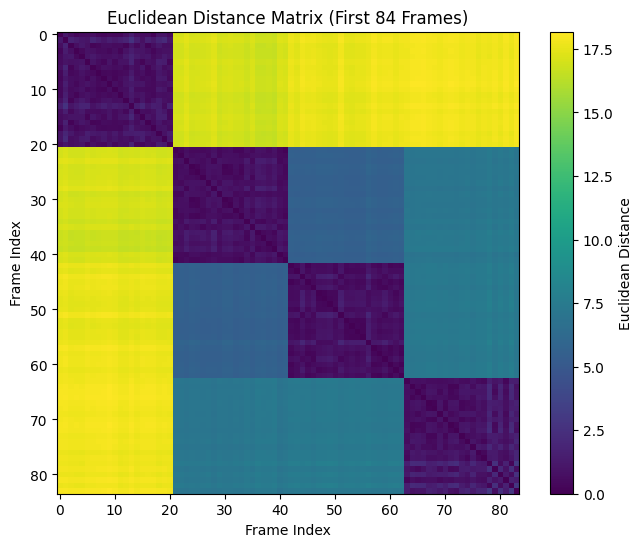

Using precomputed euclidean_precomputed distance matrix (Shape: (210, 210))

Clustering Performance (Adjusted Rand Index) [euclidean_precomputed]: 1.0000

Cluster Composition Summary:


cluster,unique_mols,mol_ids_in_cluster,representative_smiles,total_samples
u64,u32,list[str],str,u32
0,1,"[""qm9_1486""]","""[H]C([H])([H])C([H])([H])OC(=O)C([H])([H])C([H])([H])[H]""",21
1,1,"[""qm9_1246""]","""[H]C([H])([H])C(=O)C([H])([H])OC([H])([H])C([H])([H])[H]""",21
2,1,"[""qm9_1449""]","""[H]C(=O)C([H])([H])[C@@]([H])(OC([H])([H])[H])C([H])([H])[H]""",21
3,1,"[""qm9_1478""]","""[H]C([H])([H])OC(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
4,1,"[""qm9_1447""]","""[H]C(=O)O[C@]([H])(C([H])([H])[H])C([H])([H])C([H])([H])[H]""",21
5,1,"[""qm9_1237""]","""[H]OC([H])([H])C([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
6,1,"[""qm9_1476""]","""[H]OC([H])([H])C(=O)C([H])([H])C([H])([H])C([H])([H])[H]""",21
7,1,"[""qm9_1248""]","""[H]C([H])([H])OC([H])([H])C([H])([H])C(=O)C([H])([H])[H]""",21
8,1,"[""qm9_1474""]","""[H]C([H])([H])OC([H])([H])C(=O)C([H])([H])C([H])([H])[H]""",21



Chemiscope file successfully saved to: report/qm9/figures/grassmann/chemiscope_clustering_euclidean_precomputed.json.gz


<ChemiscopeWidget(meta={'name': 'chemiscope_clustering_euclidean_precomputed'}, structures=[{'size': 17, 'data…

In [11]:
from sklearn.metrics import pairwise_distances

X_euclidean = get_raw_xyz_features(frames)
dist_matrix_euclidean = pairwise_distances(X_euclidean, metric='euclidean')

plt.figure(figsize=(8, 6))
plt.imshow(dist_matrix_euclidean[:84, :84], cmap='viridis')
plt.colorbar(label='Euclidean Distance')
plt.title("Euclidean Distance Matrix (First 84 Frames)")
plt.xlabel("Frame Index")
plt.ylabel("Frame Index")
plt.show()

summary_eucl, path_eucl = make_clustering(
    frames, 
    dist_matrix=dist_matrix_euclidean, 
    metric_name="euclidean_precomputed",
)

chemiscope.show_input(path_eucl)